# Занятие 1. Текстовый датасет из интернета + AI: кластеризация психологических профилей

## Зачем нужен этот ноутбук

В этом ноутбуке мы показываем, как подключить **AI-инструменты для аналитики данных** к открытому датасету из интернета.

Здесь мы работаем с реальным текстовым датасетом, где у каждого автора есть:

- текст эссе;
- 5 психологических параметров Big Five;
- признаки личности, которые можно использовать для AI-анализа.

Главная цель занятия:

- загрузить **реальный датасет**, а не учебную таблицу;
- подготовить данные для модели;
- применить **кластеризацию**;
- объяснить результат на языке аналитика данных.

## Важный методический смысл

В дипломном проекте студенту недостаточно просто написать код. Нужно уметь пройти полный путь:

1. найти открытый датасет по теме проекта;
2. загрузить его;
3. понять структуру и очистить данные;
4. применить AI-метод;
5. сделать выводы и объяснить, зачем они нужны.

Этот ноутбук показывает именно такой путь.


## Практическая ячейка 1. Импорт библиотек и надёжная загрузка датасета из интернета

### Что делает эта ячейка
- подключает библиотеки для анализа данных, графиков и AI;
- загружает реальный датасет по URL;
- устойчиво обрабатывает возможные ошибки кодировки;
- приводит названия столбцов к удобному виду;
- автоматически исправляет разные варианты имён колонок (`cEXT`, `EXT`, `text`, `TEXT` и т.д.).

### Какие библиотеки мы используем

**`pandas`**  
Главная библиотека для работы с таблицами в Python.  
Позволяет загружать CSV, фильтровать строки, переименовывать столбцы, считать статистику и группировать данные.

**`matplotlib.pyplot`**  
Библиотека для построения графиков.  
С её помощью мы покажем результаты анализа и AI-модели.

**`StandardScaler` из `sklearn.preprocessing`**  
Масштабирует признаки: приводит их к сопоставимому масштабу.  
Это полезно перед AI-алгоритмами, чтобы один признак не доминировал над другим.

**`KMeans` из `sklearn.cluster`**  
Алгоритм кластеризации.  
Он делит объекты на группы так, чтобы похожие объекты оказывались в одном кластере.

**`silhouette_score` из `sklearn.metrics`**  
Метрика качества кластеризации.  
Помогает понять, насколько удачно модель разделила данные на группы.

**`PCA` из `sklearn.decomposition`**  
Метод уменьшения размерности.  
Позволяет показать многомерные данные на двумерном графике.

### Почему здесь есть дополнительная обработка
Открытые датасеты из интернета часто приходят неидеальными:

- текст может быть в другой кодировке;
- названия столбцов могут отличаться;
- в одном датасете колонка называется `text`, а в другом — `TEXT` или `essay`;
- психологические признаки могут называться `ext`, `cEXT`, `EXT`.

Поэтому аналитик должен уметь сделать **устойчивую загрузку**, а не рассчитывать только на «идеальный» файл.


In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Публичный датасет с текстами и Big Five признаками
url = "https://raw.githubusercontent.com/SenticNet/personality-detection/master/essays.csv"

# Шаг 1. Загружаем CSV с обработкой кодировки.
# В текстовых датасетах из интернета часто встречаются символы не в UTF-8,
# поэтому используем безопасную схему чтения.
try:
    df = pd.read_csv(url, encoding="cp1252")
except UnicodeDecodeError:
    df = pd.read_csv(url, encoding="latin1")

original_columns = df.columns.tolist()

# Шаг 2. Нормализуем имена столбцов.
# Мы приводим их к нижнему регистру, убираем лишние символы
# и переименовываем к единому стандарту.
rename_map = {}
for col in df.columns:
    clean = re.sub(r"[^a-z0-9]+", "", str(col).replace("\ufeff", "").strip().lower())

    if clean in {"text", "essay", "content", "body"}:
        rename_map[col] = "text"
    elif clean in {"authid", "authorid", "id"}:
        rename_map[col] = "author_id"
    elif clean in {"ext", "cext"}:
        rename_map[col] = "ext"
    elif clean in {"neu", "cneu"}:
        rename_map[col] = "neu"
    elif clean in {"agr", "cagr"}:
        rename_map[col] = "agr"
    elif clean in {"con", "ccon"}:
        rename_map[col] = "con"
    elif clean in {"opn", "copn"}:
        rename_map[col] = "opn"
    else:
        rename_map[col] = clean

df = df.rename(columns=rename_map)

required_columns = ["text", "ext", "neu", "agr", "con", "opn"]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(
        f"Не удалось найти обязательные столбцы: {missing_columns}. "
        f"Исходные столбцы: {original_columns}. "
        f"После нормализации: {df.columns.tolist()}"
    )

print("Датасет успешно загружен.")
print("Размер таблицы:", df.shape)
print("Исходные столбцы:", original_columns)
print("Нормализованные столбцы:", df.columns.tolist())
display(df.head(3))


Датасет успешно загружен.
Размер таблицы: (2467, 7)
Исходные столбцы: ['#AUTHID', 'TEXT', 'cEXT', 'cNEU', 'cAGR', 'cCON', 'cOPN']
Нормализованные столбцы: ['author_id', 'text', 'ext', 'neu', 'agr', 'con', 'opn']


,author_id,text,ext,neu,agr,con,opn
0,1997_504851.txt,"Well, right now I just woke up from a mid-day ...",n,y,y,n,y
1,1997_605191.txt,"Well, here we go with the stream of consciousn...",n,n,y,n,n
2,1997_687252.txt,An open keyboard and buttons to push. The thin...,n,y,n,y,y


## Практическая ячейка 2. Первичный обзор текстовых данных и параметров личности

### Что делает эта ячейка
- показывает названия столбцов;
- проверяет типы данных;
- считает частоты значений по каждому психологическому параметру;
- создаёт признаки длины текста.

### Что важно понять аналитикам
Сейчас признаки личности могут быть записаны текстом:
- `y`
- `n`

Для человека это понятно.  
Но AI-модель не умеет работать с такими обозначениями напрямую.  
Поэтому сначала мы должны понять структуру данных, а потом перевести признаки в числа.

### Алгоритм работы
1. Проверяем, какие столбцы есть в таблице.
2. Смотрим типы данных.
3. Изучаем распределение значений по 5 психологическим параметрам.
4. Создаём вспомогательные признаки: длина текста в символах и словах.


In [2]:
trait_cols = ["ext", "neu", "agr", "con", "opn"]
trait_names = {
    "ext": "Экстраверсия",
    "neu": "Нейротизм",
    "agr": "Доброжелательность",
    "con": "Добросовестность",
    "opn": "Открытость опыту",
}

print("Названия столбцов:")
print(df.columns.tolist())
print()

print("Типы данных:")
print(df.dtypes)
print()

for col in trait_cols:
    print(f"Распределение по признаку {trait_names[col]} ({col}):")
    print(df[col].astype(str).str.strip().str.lower().value_counts(dropna=False))
    print("-" * 60)

# Дополнительные текстовые признаки
df["text"] = df["text"].fillna("").astype(str)
df["text_length_chars"] = df["text"].str.len()
df["text_length_words"] = df["text"].str.split().str.len()

print("Описание длины текстов:")
display(df[["text_length_chars", "text_length_words"]].describe().round(2))


Названия столбцов:
['author_id', 'text', 'ext', 'neu', 'agr', 'con', 'opn']

Типы данных:
author_id    object
text         object
ext          object
neu          object
agr          object
con          object
opn          object
dtype: object

Распределение по признаку Экстраверсия (ext):
ext
y    1276
n    1191
Name: count, dtype: int64
------------------------------------------------------------
Распределение по признаку Нейротизм (neu):
neu
n    1234
y    1233
Name: count, dtype: int64
------------------------------------------------------------
Распределение по признаку Доброжелательность (agr):
agr
y    1310
n    1157
Name: count, dtype: int64
------------------------------------------------------------
Распределение по признаку Добросовестность (con):
con
y    1253
n    1214
Name: count, dtype: int64
------------------------------------------------------------
Распределение по признаку Открытость опыту (opn):
opn
y    1271
n    1196
Name: count, dtype: int64
--------------------

,text_length_chars,text_length_words
count,2467.00,2467.00
mean,3296.28,652.13
std,1287.28,253.96
min,159.00,33.00
25%,2408.00,472.00
50%,3164.00,626.00
75%,4079.00,806.00
max,12852.00,2500.00


## Практическая ячейка 3. Подготовка текстовых признаков для AI-модели

### Что делает эта ячейка
- переводит `y` / `n` в `1` / `0`;
- очищает значения признаков от лишних пробелов и регистра;
- удаляет строки с пропусками по ключевым столбцам;
- формирует таблицу признаков для AI;
- масштабирует признаки через `StandardScaler`.

## Самая важная идея этой ячейки

AI-алгоритмы обычно работают **с числами**, а не с текстовыми обозначениями.  
Поэтому аналитик делает этап **кодирования признаков**:

- `y` → `1`
- `n` → `0`

Это очень важный методический момент:

> реальные данные почти всегда нужно подготовить перед моделью.

## Подробно про `StandardScaler`

Допустим, один признак принимает значения от 0 до 1,  
а другой — от 0 до 1000.

Тогда алгоритм кластеризации может начать сильнее ориентироваться на признак с большими числами.  
Чтобы этого не произошло, мы приводим признаки к единому масштабу.

`StandardScaler`:
- вычитает среднее значение;
- делит на стандартное отклонение;
- в результате признак имеет среднее около 0 и стандартное отклонение около 1.


In [3]:
# Приводим текстовые признаки к единому виду и кодируем их в числа
for col in trait_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"y": 1, "n": 0})
    )

# Оставляем только строки, где есть текст и все 5 признаков
df = df.dropna(subset=trait_cols).copy()
df = df[df["text"].str.strip() != ""].copy()

# Таблица признаков для AI
X = df[trait_cols].copy()

print("Первые строки таблицы признаков для AI:")
display(X.head())

# Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Размер матрицы признаков:", X.shape)
print("Размер масштабированной матрицы:", X_scaled.shape)
print()
print("Первые 5 строк после масштабирования:")
display(pd.DataFrame(X_scaled, columns=trait_cols).head().round(3))


Первые строки таблицы признаков для AI:


,ext,neu,agr,con,opn
0,0,1,1,0,1
1,0,0,1,0,0
2,0,1,0,1,1
3,1,0,1,1,0
4,1,0,1,0,1


Размер матрицы признаков: (2467, 5)
Размер масштабированной матрицы: (2467, 5)

Первые 5 строк после масштабирования:


,ext,neu,agr,con,opn
0,-1.035,1.0,0.940,-1.016,0.970
1,-1.035,-1.0,0.940,-1.016,-1.031
2,-1.035,1.0,-1.064,0.984,0.970
3,0.966,-1.0,0.940,0.984,-1.031
4,0.966,-1.0,0.940,-1.016,0.970


## Практическая ячейка 4. Подбор количества кластеров: первый AI-анализ

### Что делает эта ячейка
- обучает несколько моделей `KMeans` с разным количеством кластеров;
- считает метрики качества;
- помогает выбрать разумное значение `k`.

## Что такое `KMeans`

`KMeans` — это алгоритм **кластеризации**, то есть обучения **без учителя**.

Это значит:

- у нас нет готовых правильных ответов;
- модель не знает заранее, кто к какой группе относится;
- она сама ищет похожие объекты и делит их на кластеры.

### Как работает KMeans по шагам

1. Мы задаём количество кластеров `k`.
2. Алгоритм выбирает `k` центров.
3. Каждый объект относится к ближайшему центру.
4. После этого центры пересчитываются.
5. Процедура повторяется, пока кластеры не стабилизируются.

## Что означает параметр `n_clusters`
Это количество групп, на которые модель разобьёт данные.

Если поставить:
- `n_clusters=2` — будет 2 группы;
- `n_clusters=4` — будет 4 группы;
- и так далее.

## Что означает `random_state`
Фиксирует случайность, чтобы при повторном запуске мы получали одинаковый результат.  
Для обучения и отчётов это очень полезно.

## Что означает `n_init`
Алгоритм KMeans несколько раз пробует разные начальные центры.  
Потом выбирает лучший результат.  
Это делает кластеризацию стабильнее.

## Что делает `fit_predict()`
Очень важная функция.

Она объединяет два шага:
- `fit()` — обучить модель;
- `predict()` — выдать номер кластера для каждого объекта.

То есть на выходе мы получаем массив, где для каждой строки датасета указан номер кластера.

## Что такое `inertia`
Это сумма квадратов расстояний от объектов до центров своих кластеров.  
Чем меньше inertia, тем плотнее объекты внутри кластеров.

Но только по inertia нельзя выбирать модель, потому что при увеличении числа кластеров она почти всегда уменьшается.

## Что такое `silhouette_score`
Это одна из самых удобных метрик качества кластеризации.

Идея простая:
- объект должен быть близок к своему кластеру;
- и далёк от соседних кластеров.

Оценка обычно лежит от `-1` до `1`:
- ближе к `1` — кластеры хорошие;
- около `0` — кластеры слабо разделены;
- меньше `0` — плохое разделение.

### Методическая рекомендация
Для учебного ноутбука важно не просто взять максимальную метрику, а выбрать такое число кластеров, которое:
- даёт понятную интерпретацию;
- не слишком дробит данные;
- удобно объясняется студентам и заказчику.


,k,inertia,silhouette_score
0,2,9808.47,0.2165
1,3,8393.90,0.2195
2,4,7469.85,0.2333
3,5,6666.38,0.2634
4,6,6093.83,0.2833


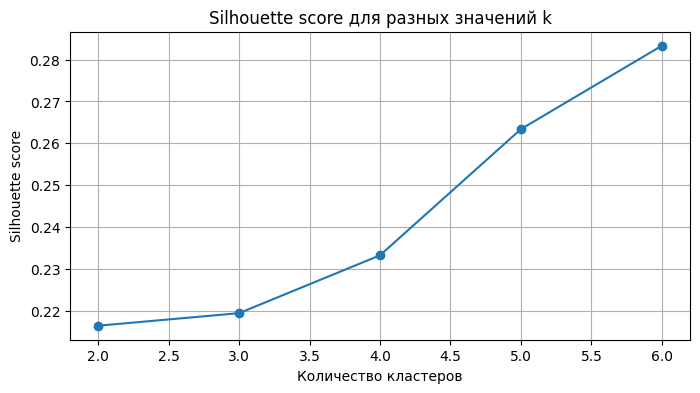

Выбранное количество кластеров для дальнейшего анализа: 4


In [4]:
model_selection_results = []

for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = model.fit_predict(X_scaled)

    model_selection_results.append(
        {
            "k": k,
            "inertia": round(model.inertia_, 2),
            "silhouette_score": round(silhouette_score(X_scaled, labels), 4),
        }
    )

selection_df = pd.DataFrame(model_selection_results)

display(selection_df)

plt.figure(figsize=(8, 4))
plt.plot(selection_df["k"], selection_df["silhouette_score"], marker="o")
plt.title("Silhouette score для разных значений k")
plt.xlabel("Количество кластеров")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

# Для учебной интерпретации возьмём 4 кластера:
# это разумный баланс между качеством разделения и понятностью групп
final_k = 4
print("Выбранное количество кластеров для дальнейшего анализа:", final_k)


## Практическая ячейка 5. Обучение AI-модели кластеризации и построение профиля кластеров

### Что делает эта ячейка
- обучает итоговую модель `KMeans`;
- присваивает каждому автору номер кластера;
- считает размеры кластеров;
- строит усреднённый психологический профиль каждой группы.

## Что важно понять
После этой ячейки у нас появляется новый столбец:

- `cluster`

Это уже результат работы AI-модели.

Теперь каждый автор относится к некоторой группе, например:
- кластер 0,
- кластер 1,
- кластер 2,
- кластер 3.

### Что означают центры кластеров
У KMeans у каждого кластера есть **центр**.  
Это как "средний профиль" группы.

Если кластер имеет высокий средний показатель по экстраверсии и низкий по нейротизму, мы можем интерпретировать этот кластер как один из психологических типов.

### Что делает `groupby().mean()`
После кластеризации нам мало просто получить номера групп.  
Нужно понять, **чем кластеры отличаются**.

Для этого мы:
1. группируем данные по номеру кластера;
2. считаем средние значения признаков внутри каждой группы.

Так рождается **аналитическая интерпретация AI-модели**.

### Почему это важно для диплома
В дипломном проекте недостаточно написать:
> "Я обучил модель и получил 4 кластера."

Нужно дальше объяснить:
- что это за кластеры;
- чем они отличаются;
- какую бизнес- или предметную пользу это даёт.


In [5]:
# Обучаем итоговую модель
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init="auto")
df["cluster"] = kmeans.fit_predict(X_scaled)

# Размеры кластеров
cluster_sizes = df["cluster"].value_counts().sort_index()

# Профиль кластеров: средние значения признаков внутри каждой группы
cluster_profile = df.groupby("cluster")[trait_cols + ["text_length_words"]].mean().round(2)

# Русские названия для красивого вывода
cluster_profile_ru = cluster_profile.rename(
    columns={**trait_names, "text_length_words": "Средняя длина текста (слов)"}
)

print("Размеры кластеров:")
display(cluster_sizes)

print("Профиль кластеров:")
display(cluster_profile_ru)

# Автоматическое текстовое описание кластера
def describe_cluster(row):
    high = [trait_names[c] for c in trait_cols if row[c] >= 0.6]
    low = [trait_names[c] for c in trait_cols if row[c] <= 0.4]

    high_text = ", ".join(high) if high else "нет ярко выраженных высоких параметров"
    low_text = ", ".join(low) if low else "нет ярко выраженных низких параметров"

    return f"Высокие: {high_text}. Низкие: {low_text}."

cluster_descriptions = {
    cluster_id: describe_cluster(cluster_profile.loc[cluster_id])
    for cluster_id in cluster_profile.index
}

print("Текстовая интерпретация кластеров:")
for cluster_id, description in cluster_descriptions.items():
    print(f"Кластер {cluster_id}: {description}")


Размеры кластеров:


,count
cluster,
0,438
1,448
2,835
3,746


Профиль кластеров:


,Экстраверсия,Нейротизм,Доброжелательность,Добросовестность,Открытость опыту,Средняя длина текста (слов)
cluster,,,,,,
0,0.80,0.16,0.84,0.84,0.00,638.78
1,0.12,0.72,1.00,0.26,0.42,645.48
2,0.30,0.75,0.00,0.29,0.40,652.61
3,0.84,0.29,0.66,0.70,1.00,663.43


Текстовая интерпретация кластеров:
Кластер 0: Высокие: Экстраверсия, Доброжелательность, Добросовестность. Низкие: Нейротизм, Открытость опыту.
Кластер 1: Высокие: Нейротизм, Доброжелательность. Низкие: Экстраверсия, Добросовестность.
Кластер 2: Высокие: Нейротизм. Низкие: Экстраверсия, Доброжелательность, Добросовестность, Открытость опыту.
Кластер 3: Высокие: Экстраверсия, Доброжелательность, Добросовестность, Открытость опыту. Низкие: Нейротизм.


## Практическая ячейка 6. Визуализация AI-результатов: PCA, scatter plot и тепловая карта профилей

### Что делает эта ячейка
- уменьшает размерность данных с 5 признаков до 2 компонент;
- строит scatter plot кластеров;
- показывает размеры кластеров;
- показывает тепловую карту средних профилей.

## Зачем нужен `PCA`
У нас 5 признаков личности:

- экстраверсия
- нейротизм
- доброжелательность
- добросовестность
- открытость опыту

Показать 5-мерное пространство на обычном графике нельзя.  
Поэтому мы применяем **PCA**.

### Что такое PCA простыми словами
`PCA` — это алгоритм, который старается сохранить как можно больше информации, но представить данные в меньшем количестве измерений.

В нашем случае:
- было 5 признаков,
- стало 2 главные компоненты,
- и теперь данные можно нарисовать на плоскости.

### Что делает `fit_transform()` у PCA
- изучает структуру данных;
- вычисляет главные компоненты;
- сразу переводит данные в новое пространство координат.

## Что такое `explained_variance_ratio_`
Показывает, какую долю информации объясняет каждая главная компонента.

Например:
- первая компонента объясняет 29% разброса,
- вторая — 20%.

Это помогает понять, насколько честно 2D-график отражает исходные данные.

## Почему эта ячейка очень важна
Здесь аналитик превращает "сухой" AI-результат в понятную картинку.

Заказчик, преподаватель или член комиссии часто лучше понимает:
- не таблицу с центрами кластеров,
- а график, где видны группы и различия между ними.


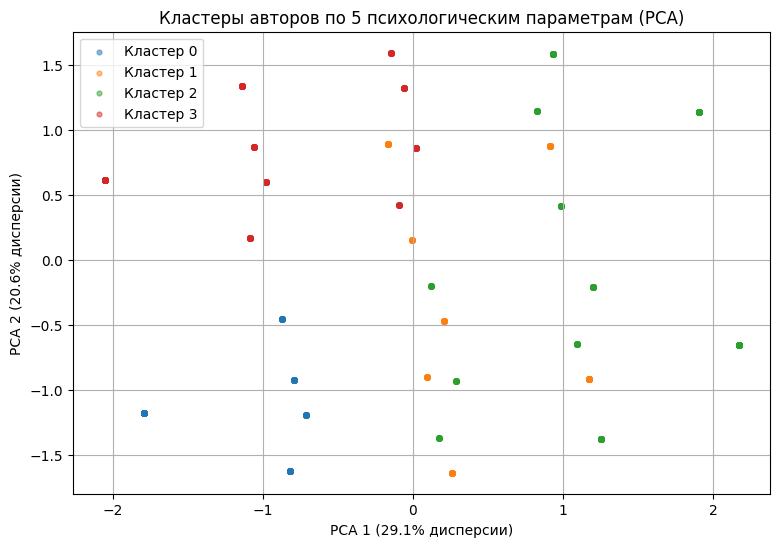

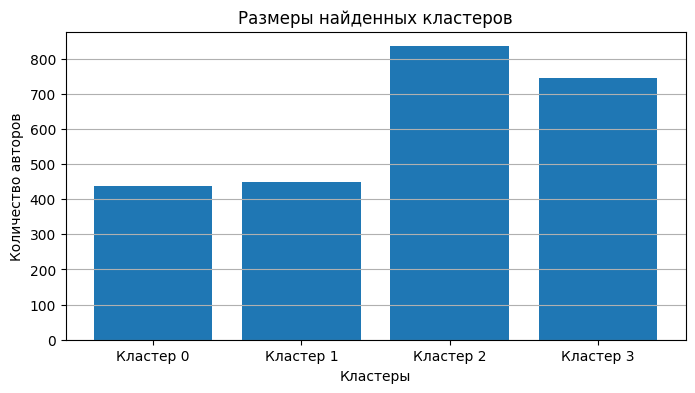

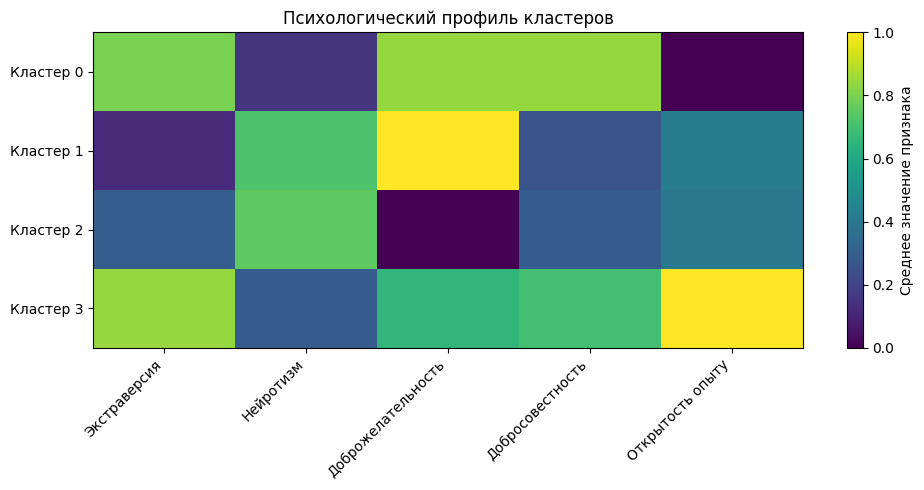

In [6]:
# PCA для отображения кластеров на плоскости
pca = PCA(n_components=2, random_state=42)
pca_coordinates = pca.fit_transform(X_scaled)

df["pca1"] = pca_coordinates[:, 0]
df["pca2"] = pca_coordinates[:, 1]

# График 1. Кластеры на плоскости
plt.figure(figsize=(9, 6))
for cluster_id in sorted(df["cluster"].unique()):
    cluster_data = df[df["cluster"] == cluster_id]
    plt.scatter(
        cluster_data["pca1"],
        cluster_data["pca2"],
        s=12,
        alpha=0.5,
        label=f"Кластер {cluster_id}",
    )

plt.title("Кластеры авторов по 5 психологическим параметрам (PCA)")
plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%} дисперсии)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%} дисперсии)")
plt.legend()
plt.grid(True)
plt.show()

# График 2. Размеры кластеров
plt.figure(figsize=(8, 4))
plt.bar([f"Кластер {i}" for i in cluster_sizes.index], cluster_sizes.values)
plt.title("Размеры найденных кластеров")
plt.xlabel("Кластеры")
plt.ylabel("Количество авторов")
plt.grid(axis="y")
plt.show()

# График 3. "Тепловая карта" профиля кластера по 5 признакам
plt.figure(figsize=(10, 5))
plt.imshow(cluster_profile[trait_cols].values, aspect="auto")
plt.colorbar(label="Среднее значение признака")
plt.xticks(
    range(len(trait_cols)),
    [trait_names[c] for c in trait_cols],
    rotation=45,
    ha="right",
)
plt.yticks(
    range(len(cluster_profile.index)),
    [f"Кластер {i}" for i in cluster_profile.index],
)
plt.title("Психологический профиль кластеров")
plt.tight_layout()
plt.show()


## Практическая ячейка 7. Выводы по AI-анализу и связь с дипломным проектом

### Что делает эта ячейка
- формулирует выводы на основе кластеризации;
- показывает, как переводить результат AI в аналитический язык;
- связывает упражнение с будущим дипломным проектом.

### Что должен уметь студент после этой ячейки
Студент должен уметь сказать не только:
- "Я применил KMeans",

но и:
- "Я нашёл несколько типов объектов";
- "Я объяснил, чем эти группы отличаются";
- "Я показал это на графиках";
- "Я понял, как это можно использовать в дипломном проекте".

### Главная идея
Для диплома важно не просто скачать датасет.  
Нужно пройти весь аналитический путь:

1. найти данные по теме проекта;
2. понять, какие признаки доступны;
3. подготовить данные;
4. выбрать метод AI или аналитики;
5. интерпретировать результат;
6. сделать осмысленные выводы.


In [7]:
dominant_cluster = cluster_sizes.idxmax()
dominant_cluster_size = cluster_sizes.max()

most_extraverted_cluster = cluster_profile["ext"].idxmax()
least_neurotic_cluster = cluster_profile["neu"].idxmin()
longest_text_cluster = cluster_profile["text_length_words"].idxmax()

print("Выводы по AI-анализу:")
print()

print(
    f"1. Модель KMeans разделила авторов на {final_k} кластера. "
    f"Самый крупный кластер — {dominant_cluster}, в нём {dominant_cluster_size} авторов."
)
print()

print(
    f"2. Наиболее выраженная экстраверсия наблюдается у кластера {most_extraverted_cluster}. "
    f"Это означает, что внутри этой группы чаще встречается высокий уровень экстраверсии."
)
print()

print(
    f"3. Самый низкий средний нейротизм у кластера {least_neurotic_cluster}. "
    f"Такой кластер можно интерпретировать как более эмоционально устойчивую группу."
)
print()

print(
    f"4. Самые длинные тексты в среднем пишет кластер {longest_text_cluster}. "
    f"Это показывает, что найденные группы могут отличаться не только психологическими параметрами, "
    f"но и стилем текстового поведения."
)
print()

print("5. Для дипломного проекта логика должна быть такой же:")
print("   - найти датасет по теме диплома;")
print("   - понять, какие признаки в нём есть;")
print("   - при необходимости перевести текстовые признаки в числовые;")
print("   - применить AI-метод: прогноз, кластеризацию, классификацию или другой анализ;")
print("   - показать результат в виде таблиц, графиков и понятных выводов.")


Выводы по AI-анализу:

1. Модель KMeans разделила авторов на 4 кластера. Самый крупный кластер — 2, в нём 835 авторов.

2. Наиболее выраженная экстраверсия наблюдается у кластера 3. Это означает, что внутри этой группы чаще встречается высокий уровень экстраверсии.

3. Самый низкий средний нейротизм у кластера 0. Такой кластер можно интерпретировать как более эмоционально устойчивую группу.

4. Самые длинные тексты в среднем пишет кластер 3. Это показывает, что найденные группы могут отличаться не только психологическими параметрами, но и стилем текстового поведения.

5. Для дипломного проекта логика должна быть такой же:
   - найти датасет по теме диплома;
   - понять, какие признаки в нём есть;
   - при необходимости перевести текстовые признаки в числовые;
   - применить AI-метод: прогноз, кластеризацию, классификацию или другой анализ;
   - показать результат в виде таблиц, графиков и понятных выводов.


## Что студент должен вынести из этого занятия

После выполнения ноутбука вы должны понимать:

- текстовые признаки тоже можно превратить в данные для AI;
- перед моделью почти всегда есть этап подготовки данных;
- кластеризация — это поиск скрытых групп без готовых ответов;
- AI-ячейки нельзя воспринимать как магию: каждая функция имеет понятную роль;
- для диплома важно не только применить модель, но и **объяснить результат**.

## Идея для самостоятельной работы

Попробуйте изменить ноутбук:

1. взять для кластеризации не только 5 параметров Big Five, но и длину текста;
2. сравнить результаты при `k = 3`, `k = 4`, `k = 5`;
3. придумать содержательные названия кластерам;
4. подобрать реальный датасет по теме своего будущего диплома и повторить тот же цикл анализа.
